In [1]:
from src.baseline_config import build_training_config
import src.ModelTrain as ModelTrain
from src.phase0.split import create_baseline_split
from src.phase1.config import PHASE1_RUNS
from src.phase1.experiment import (
    print_phase1_summary,
    run_phase1_experiments,
    show_phase1_plots,
)
from utils.metrics import print_results_metrics_summary

TRAINING_CONFIG = build_training_config(architecture="efficientnet_b0")

In [2]:
train_df, validation_df = create_baseline_split(overwrite=False)

print("Train class distribution:")
print(ModelTrain.get_class_counts(train_df).to_string())
print(sum(ModelTrain.get_class_counts(train_df)))

print("\nValidation class distribution:")
print(ModelTrain.get_class_counts(validation_df).to_string())
print(sum(ModelTrain.get_class_counts(validation_df)))

Train class distribution:
histology
Adenoma                     1578
Sessile_serrated_adenoma     725
Hyperplastic                 334
Adenocarcinoma               101
2738

Validation class distribution:
histology
Adenoma                     395
Sessile_serrated_adenoma    182
Hyperplastic                 84
Adenocarcinoma               19
680


In [3]:
run_phase1_experiments(training_config=TRAINING_CONFIG, force_train=False)

Loading model located at: C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase1\seed1\best_baseline_model.pth
Loading model located at: C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase1\seed2\best_baseline_model.pth
Loading model located at: C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase1\seed3\best_baseline_model.pth
Loading model located at: C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase1\seed4\best_baseline_model.pth


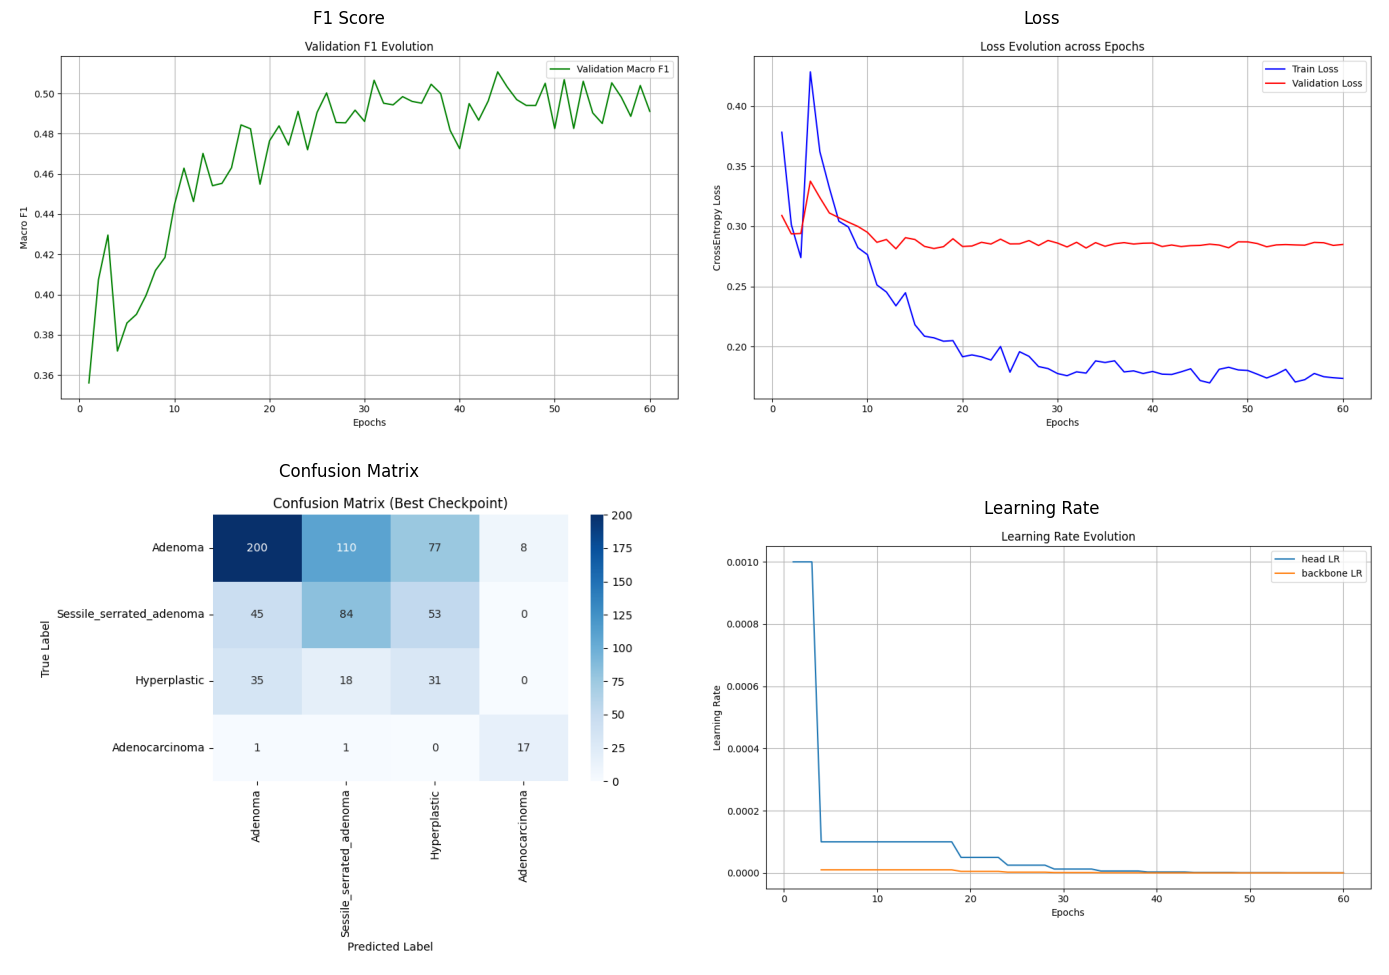

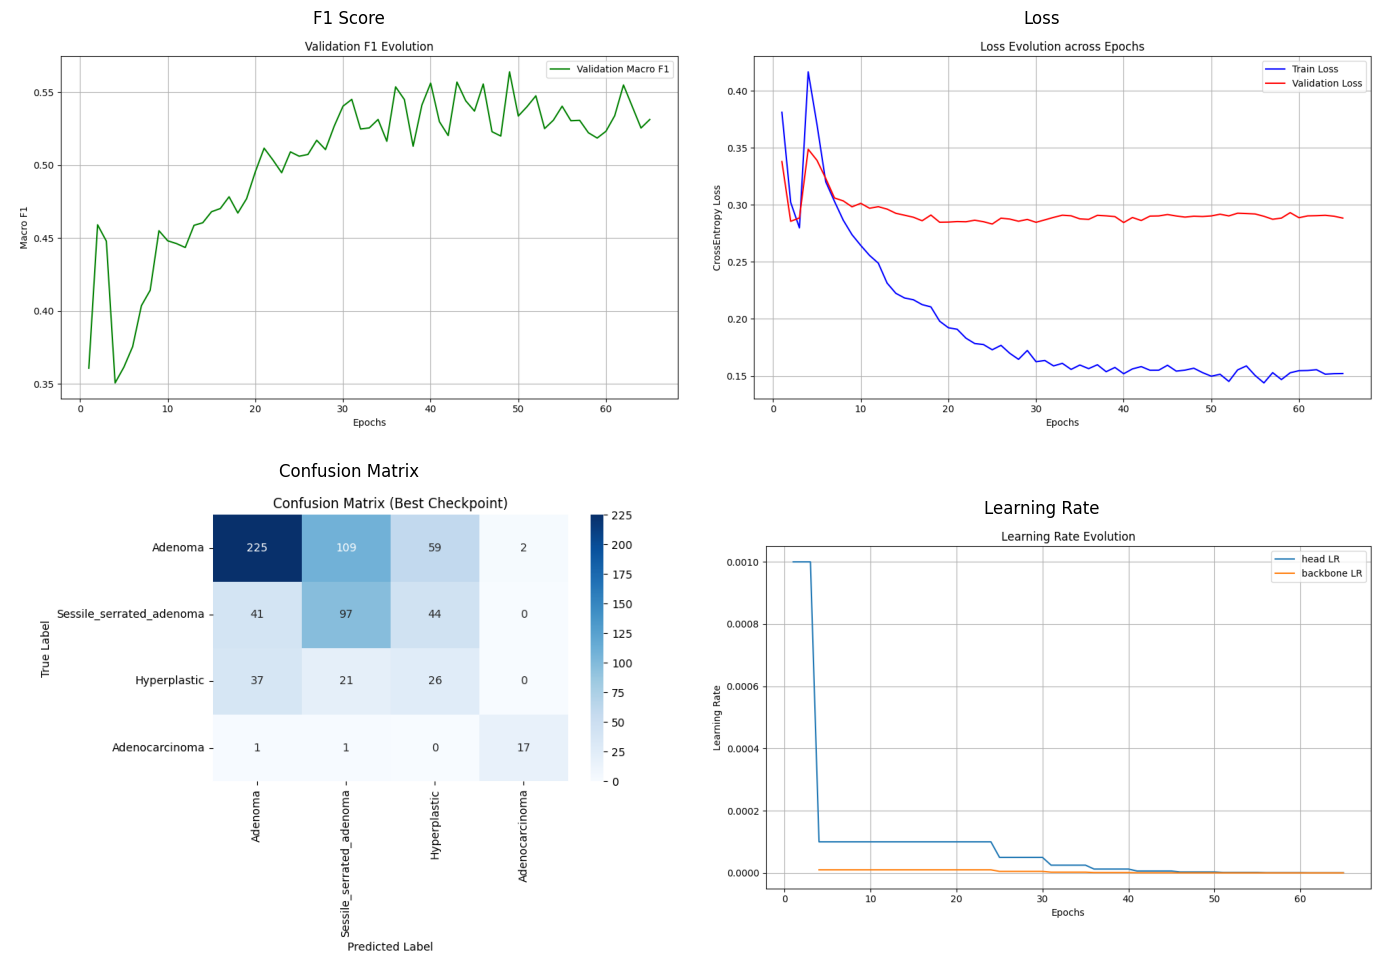

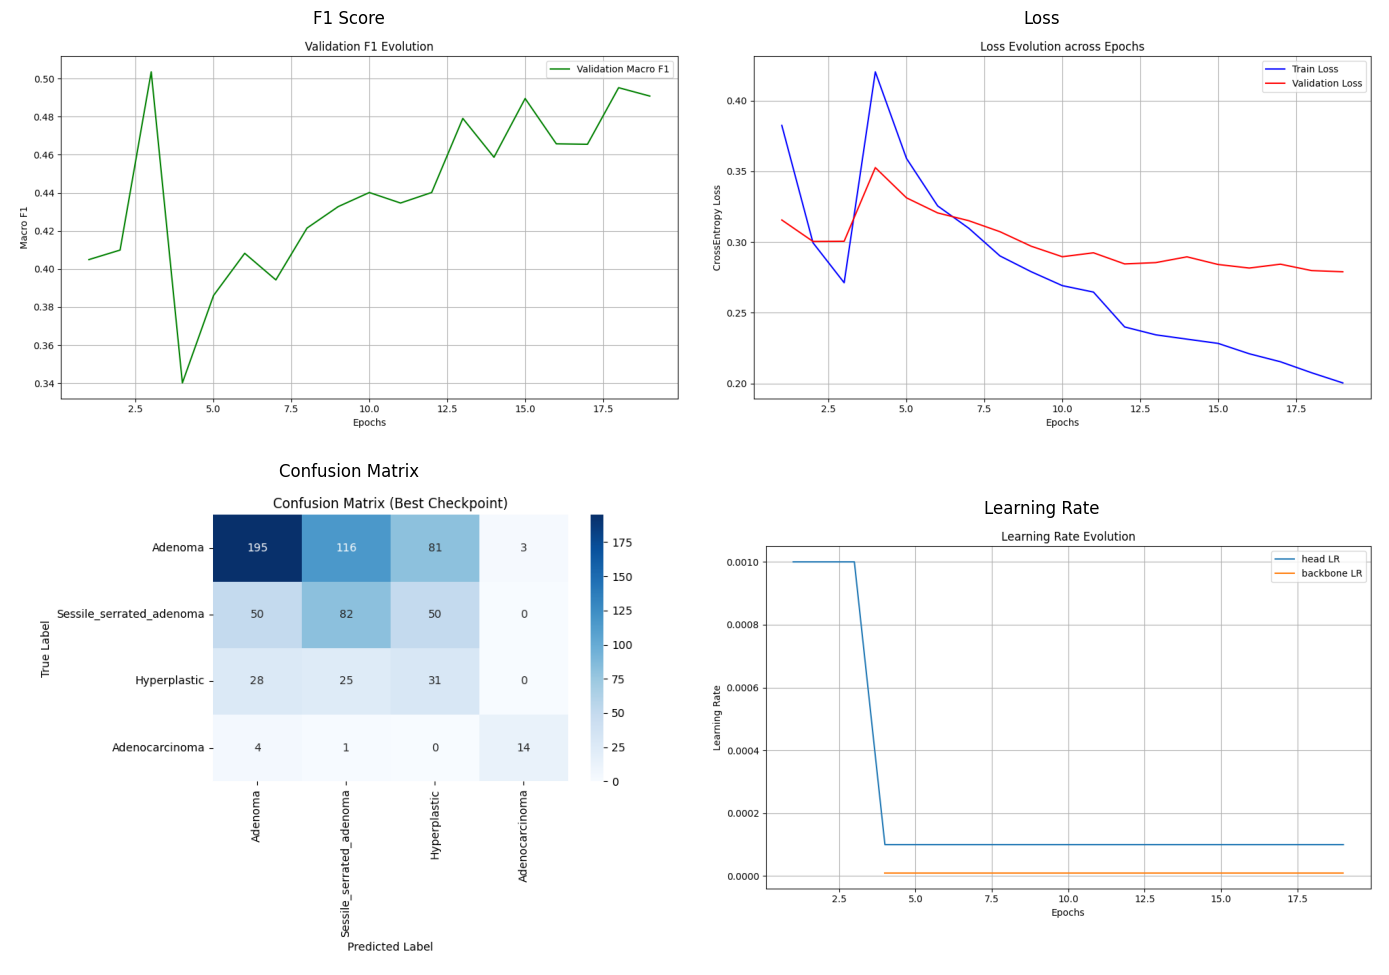

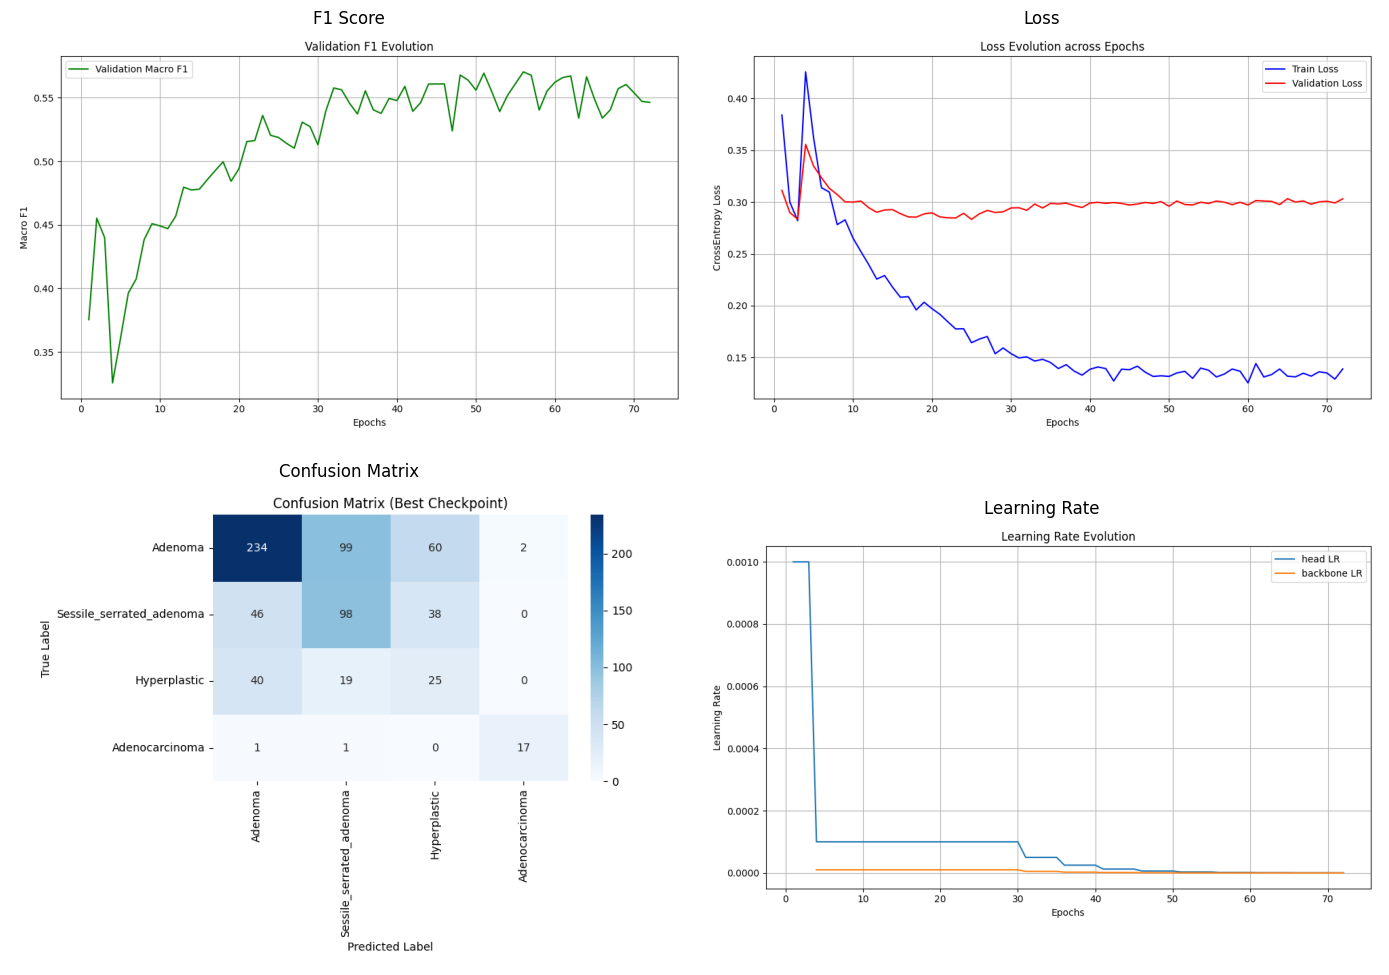

In [4]:
show_phase1_plots(training_config=TRAINING_CONFIG)

In [5]:
print_phase1_summary(training_config=TRAINING_CONFIG)

,scope,accuracy,mcc,macro_f1,precision,recall
0,general,0.5121 +/- 0.0370,0.2372 +/- 0.0404,0.5371 +/- 0.0349,0.5378 +/- 0.0361,0.5570 +/- 0.0313
1,Adenoma,0.6121 +/- 0.0262,0.2509 +/- 0.0423,0.6174 +/- 0.0367,0.7212 +/- 0.0164,0.5405 +/- 0.0480
2,Sessile_serrated_adenoma,0.6735 +/- 0.0243,0.2217 +/- 0.0580,0.4484 +/- 0.0407,0.4094 +/- 0.0372,0.4959 +/- 0.0463
3,Hyperplastic,0.7482 +/- 0.0209,0.1152 +/- 0.0012,0.2477 +/- 0.0057,0.1972 +/- 0.0061,0.3363 +/- 0.0381
4,Adenocarcinoma,0.9904 +/- 0.0044,0.8324 +/- 0.0685,0.8350 +/- 0.0690,0.8233 +/- 0.1012,0.8553 +/- 0.0789


In [6]:
print_results_metrics_summary(
    results_dirs=[run["results_dir"] for run in PHASE1_RUNS],
    validation_csv_dir="test/external_test.csv",
    validation_img_dir="test/images_cropped",
    training_config=TRAINING_CONFIG,
    random_states=[run["random_state"] for run in PHASE1_RUNS],
)

,scope,accuracy,mcc,macro_f1,precision,recall
0,general,0.4263 +/- 0.0110,0.3008 +/- 0.0090,0.3774 +/- 0.0082,0.4831 +/- 0.0223,0.4830 +/- 0.0191
1,Adenoma,0.6863 +/- 0.0144,0.2493 +/- 0.0168,0.4716 +/- 0.0094,0.4685 +/- 0.0221,0.4765 +/- 0.0285
2,Sessile_serrated_adenoma,0.6537 +/- 0.0342,0.0877 +/- 0.0239,0.0557 +/- 0.0077,0.0290 +/- 0.0040,0.6944 +/- 0.0962
3,Hyperplastic,0.6859 +/- 0.0154,0.1407 +/- 0.0584,0.2669 +/- 0.0503,0.4909 +/- 0.0712,0.1836 +/- 0.0378
4,Adenocarcinoma,0.8268 +/- 0.0125,0.6395 +/- 0.0229,0.7155 +/- 0.0300,0.9438 +/- 0.0140,0.5774 +/- 0.0437
